# Bus Service Reliability Prediction Using BODS Timetable Data

In [60]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("BusServiceReliability")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)

print("Spark Version:", spark.version)

Spark Version: 4.1.1


In [61]:
import os

dataset_path = "../data/timetable"

print("Files in timetable folder:")
print(os.listdir(dataset_path))

Files in timetable folder:
['extracted', 'timetable.zip']


## Extract Dataset

In [62]:
import zipfile
import os

zip_path = "../data/timetable/timetable.zip"
extract_path = "../data/timetable/extracted"

# Create folder if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Extract
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [63]:
import os

files = os.listdir("../data/timetable/extracted")

print("Number of extracted files:", len(files))
print(files[:10])  # Show the first 10 files

Number of extracted files: 123
['783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_549_20251023-BODS_V1_1.xml', '717-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_537_20251023-BODS_V1_1.xml', 'PB726-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_560_20251023-BODS_V1_1.xml', '609-None--SCMY-RF-2026-03-29-Birkenhead_March_2026-Refresh2__SCMY_PC1033334_595_20260329-BODS_V1_1.xml', 'CH23-None--SCMY-CZ-2026-03-29-Chester_July_2026_(SchOut)__SCMY_PC1033334_628_20260719-BODS_V1_1.xml', '786-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_525_20251023-BODS_V1_1.xml', 'ME14-None--SCMY-GM-2026-07-26-Gillmoss_July_2026_EV_ADDED_FINAL__SCMY_PC1033334_3_20260719-BODS_V1_1.xml', '708-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_536_20251023-BODS_V1_1.xml', '787-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_551_20251023-BODS_V1_1.xml', '

In [64]:
import os

folder = "../data/timetable/extracted"

first_file = os.listdir(folder)[0]

print(first_file)

783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_549_20251023-BODS_V1_1.xml


In [65]:
with open(f"{folder}/{first_file}", "r", encoding="utf-8") as f:
    for i in range(50):
        print(f.readline().strip())

<?xml version='1.0' encoding='utf-8'?>
<!--Created by Optibus TransXChange Exporter (1.0.2)-->
<TransXChange xmlns="http://www.transxchange.org.uk/" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" CreationDateTime="2022-08-19T12:05:39" ModificationDateTime="2025-10-22T10:07:01" Modification="revise" RevisionNumber="1088" FileName="783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van-BODS_V1_1.xml" SchemaVersion="2.4" RegistrationDocument="false" xsi:schemaLocation="http://www.transxchange.org.uk/ http://www.transxchange.org.uk/schema/2.4/TransXChange_general.xsd">
<ServicedOrganisations>
<ServicedOrganisation>
<OrganisationCode>MYGM001</OrganisationCode>
<Name>Merseytravel Schools</Name>
<WorkingDays>
<DateRange>
<StartDate>2025-09-01</StartDate>
<EndDate>2025-10-24</EndDate>
<Description>Merseytravel Schools</Description>
</DateRange>
<DateRange>
<StartDate>2025-11-03</StartDate>
<EndDate>2025-12-19</EndDate>
<Description>Merseytravel Schools</Description>
</DateRange>


## Parse XML Files

In [66]:
import os
import xml.etree.ElementTree as ET

folder = "../data/timetable/extracted"

records = []

namespace = {"tx": "http://www.transxchange.org.uk/"}

for file in os.listdir(folder):

    if not file.endswith(".xml"):
        continue

    filepath = os.path.join(folder, file)

    try:
        tree = ET.parse(filepath)
        root = tree.getroot()

        creation = root.attrib.get("CreationDateTime")
        modified = root.attrib.get("ModificationDateTime")

        organisation = root.find(".//tx:OrganisationCode", namespace)
        organisation_name = root.find(".//tx:Name", namespace)

        stop = root.find(".//tx:AnnotatedStopPointRef", namespace)

        stop_id = None
        stop_name = None

        if stop is not None:
            ref = stop.find("tx:StopPointRef", namespace)
            name = stop.find("tx:CommonName", namespace)

            if ref is not None:
                stop_id = ref.text

            if name is not None:
                stop_name = name.text

        records.append({
            "filename": file,
            "creation_time": creation,
            "modified_time": modified,
            "organisation_code": organisation.text if organisation is not None else None,
            "organisation_name": organisation_name.text if organisation_name is not None else None,
            "first_stop_id": stop_id,
            "first_stop_name": stop_name
        })

    except Exception as e:
        print(file, e)
    

In [67]:
print(len(records))

123


## Create Spark DataFrame

In [86]:
# Convert Python list to Spark DataFrame
df = spark.createDataFrame(records)

# Display the first 5 rows
df.show(5, truncate=False)

+-------------------+----------------------------------------------------------------------------------------------------------+---------+-------------------+------------------+---------------+----------+---------------------+-------------+
|creation_time      |filename                                                                                                  |line_name|modified_time      |number_of_journeys|number_of_stops|operator  |route_description    |service_code |
+-------------------+----------------------------------------------------------------------------------------------------------+---------+-------------------+------------------+---------------+----------+---------------------+-------------+
|2022-08-19T12:05:39|783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_549_20251023-BODS_V1_1.xml  |783      |2025-10-22T10:07:01|2                 |62             |Stagecoach|Merseytravel Schools |PC1033334:549|
|2022-08-19T12:05:39|717-None--SCMY-

In [87]:
df.printSchema()

root
 |-- creation_time: string (nullable = true)
 |-- filename: string (nullable = true)
 |-- line_name: string (nullable = true)
 |-- modified_time: string (nullable = true)
 |-- number_of_journeys: long (nullable = true)
 |-- number_of_stops: long (nullable = true)
 |-- operator: string (nullable = true)
 |-- route_description: string (nullable = true)
 |-- service_code: string (nullable = true)



In [88]:
print("Total records:", df.count())

Total records: 123


In [89]:
print("Number of columns:", len(df.columns))

Number of columns: 9


In [90]:
print(df.columns)

['creation_time', 'filename', 'line_name', 'modified_time', 'number_of_journeys', 'number_of_stops', 'operator', 'route_description', 'service_code']


In [91]:
from pyspark.sql.functions import col, sum

df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).show()

+-------------+--------+---------+-------------+------------------+---------------+--------+-----------------+------------+
|creation_time|filename|line_name|modified_time|number_of_journeys|number_of_stops|operator|route_description|service_code|
+-------------+--------+---------+-------------+------------------+---------------+--------+-----------------+------------+
|            0|       0|        0|            0|                 0|              0|       0|                0|           0|
+-------------+--------+---------+-------------+------------------+---------------+--------+-----------------+------------+



In [92]:
import xml.etree.ElementTree as ET

tree = ET.parse("../data/timetable/extracted/" + first_file)
root = tree.getroot()

namespace = {"tx": "http://www.transxchange.org.uk/"}

for child in root:
    print(child.tag)

{http://www.transxchange.org.uk/}ServicedOrganisations
{http://www.transxchange.org.uk/}StopPoints
{http://www.transxchange.org.uk/}RouteSections
{http://www.transxchange.org.uk/}Routes
{http://www.transxchange.org.uk/}JourneyPatternSections
{http://www.transxchange.org.uk/}Operators
{http://www.transxchange.org.uk/}Services
{http://www.transxchange.org.uk/}VehicleJourneys


In [93]:
import os
import xml.etree.ElementTree as ET

namespace = {"tx": "http://www.transxchange.org.uk/"}
folder = "../data/timetable/extracted"

records = []

for file in os.listdir(folder):

    if not file.endswith(".xml"):
        continue

    path = os.path.join(folder, file)

    try:
        tree = ET.parse(path)
        root = tree.getroot()

        # XML attributes
        creation = root.attrib.get("CreationDateTime")
        modified = root.attrib.get("ModificationDateTime")

        # Operator
        operator = root.find(".//tx:OperatorShortName", namespace)
        if operator is None:
            operator = root.find(".//tx:OperatorNameOnLicence", namespace)

        # Service
        service_code = root.find(".//tx:ServiceCode", namespace)

        # Line
        line_name = root.find(".//tx:LineName", namespace)

        # Route description
        route_description = root.find(".//tx:Description", namespace)

        # Number of stops
        stop_count = len(root.findall(".//tx:AnnotatedStopPointRef", namespace))

        # Number of vehicle journeys
        journey_count = len(root.findall(".//tx:VehicleJourney", namespace))

        records.append({
            "filename": file,
            "creation_time": creation,
            "modified_time": modified,
            "operator": operator.text if operator is not None else None,
            "service_code": service_code.text if service_code is not None else None,
            "line_name": line_name.text if line_name is not None else None,
            "route_description": route_description.text if route_description is not None else None,
            "number_of_stops": stop_count,
            "number_of_journeys": journey_count
        })

    except Exception as e:
        print(file, e)

In [94]:
df = spark.createDataFrame(records)

df.show(10, truncate=False)

+-------------------+----------------------------------------------------------------------------------------------------------+---------+-------------------+------------------+---------------+----------+-----------------------+-------------+
|creation_time      |filename                                                                                                  |line_name|modified_time      |number_of_journeys|number_of_stops|operator  |route_description      |service_code |
+-------------------+----------------------------------------------------------------------------------------------------------+---------+-------------------+------------------+---------------+----------+-----------------------+-------------+
|2022-08-19T12:05:39|783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_549_20251023-BODS_V1_1.xml  |783      |2025-10-22T10:07:01|2                 |62             |Stagecoach|Merseytravel Schools   |PC1033334:549|
|2022-08-19T12:05:39|717-Non

In [95]:
df.printSchema()

root
 |-- creation_time: string (nullable = true)
 |-- filename: string (nullable = true)
 |-- line_name: string (nullable = true)
 |-- modified_time: string (nullable = true)
 |-- number_of_journeys: long (nullable = true)
 |-- number_of_stops: long (nullable = true)
 |-- operator: string (nullable = true)
 |-- route_description: string (nullable = true)
 |-- service_code: string (nullable = true)



In [96]:
df.describe().show()

[Stage 35:>                                                       (0 + 12) / 12]

+-------+-------------------+--------------------+------------------+-------------------+------------------+-----------------+----------+--------------------+-------------+
|summary|      creation_time|            filename|         line_name|      modified_time|number_of_journeys|  number_of_stops|  operator|   route_description| service_code|
+-------+-------------------+--------------------+------------------+-------------------+------------------+-----------------+----------+--------------------+-------------+
|  count|                123|                 123|               123|                123|               123|              123|       123|                 123|          123|
|   mean|               NULL|                NULL| 512.7017543859649|               NULL| 55.82113821138211| 62.9349593495935|      NULL|                NULL|         NULL|
| stddev|               NULL|                NULL|312.18873148736697|               NULL|110.08044990438981|49.09037163740293|      NUL

In [97]:
df.show(10, truncate=False)

+-------------------+----------------------------------------------------------------------------------------------------------+---------+-------------------+------------------+---------------+----------+-----------------------+-------------+
|creation_time      |filename                                                                                                  |line_name|modified_time      |number_of_journeys|number_of_stops|operator  |route_description      |service_code |
+-------------------+----------------------------------------------------------------------------------------------------------+---------+-------------------+------------------+---------------+----------+-----------------------+-------------+
|2022-08-19T12:05:39|783-None--SCMY-GM-2025-08-31-Gillmoss_September_2025_LIVE_Van__SCMY_PC1033334_549_20251023-BODS_V1_1.xml  |783      |2025-10-22T10:07:01|2                 |62             |Stagecoach|Merseytravel Schools   |PC1033334:549|
|2022-08-19T12:05:39|717-Non

## Exploratory Data Analysis (EDA)

In [98]:
print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))

Number of rows: 123
Number of columns: 9


In [99]:
print(df.columns)

['creation_time', 'filename', 'line_name', 'modified_time', 'number_of_journeys', 'number_of_stops', 'operator', 'route_description', 'service_code']


In [100]:
from pyspark.sql.functions import col, sum

missing = df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])

missing.show()

+-------------+--------+---------+-------------+------------------+---------------+--------+-----------------+------------+
|creation_time|filename|line_name|modified_time|number_of_journeys|number_of_stops|operator|route_description|service_code|
+-------------+--------+---------+-------------+------------------+---------------+--------+-----------------+------------+
|            0|       0|        0|            0|                 0|              0|       0|                0|           0|
+-------------+--------+---------+-------------+------------------+---------------+--------+-----------------+------------+



In [101]:
df.describe().show()

+-------+-------------------+--------------------+------------------+-------------------+------------------+-----------------+----------+--------------------+-------------+
|summary|      creation_time|            filename|         line_name|      modified_time|number_of_journeys|  number_of_stops|  operator|   route_description| service_code|
+-------+-------------------+--------------------+------------------+-------------------+------------------+-----------------+----------+--------------------+-------------+
|  count|                123|                 123|               123|                123|               123|              123|       123|                 123|          123|
|   mean|               NULL|                NULL| 512.7017543859649|               NULL| 55.82113821138211| 62.9349593495935|      NULL|                NULL|         NULL|
| stddev|               NULL|                NULL|312.18873148736697|               NULL|110.08044990438981|49.09037163740293|      NUL

In [102]:
from pyspark.sql.functions import desc

df.select(
    "line_name",
    "route_description",
    "number_of_stops"
).orderBy(desc("number_of_stops")).show(10, truncate=False)

+---------+---------------------------------------------------+---------------+
|line_name|route_description                                  |number_of_stops|
+---------+---------------------------------------------------+---------------+
|38       |Eastham Ferry - West Kirby                         |269            |
|217      |Tower Hill - Huyton                                |231            |
|2        |CZ Helsby High School                              |215            |
|16       |Moreton Cross - Eastham Rake Railway Station       |204            |
|X1       |Chester Railway Station - Liverpool via Zoo        |192            |
|84       |Chester Interchange, Stand L - Crewe Bus Station, 5|186            |
|41       |Mill Park - Woodchurch                             |177            |
|774      |Merseytravel Schools                               |151            |
|14       |Liverpool - Tower Hill                             |150            |
|603      |RF Wirral Schools            

In [103]:
df.select(
    "line_name",
    "route_description",
    "number_of_journeys"
).orderBy(desc("number_of_journeys")).show(10, truncate=False)

+---------+-------------------------------------------+------------------+
|line_name|route_description                          |number_of_journeys|
+---------+-------------------------------------------+------------------+
|20       |Paradise St - Towerhill                    |574               |
|82       |Paradise St - Garston                      |448               |
|86       |Liverpool ONE - South Parkway              |403               |
|17       |Liverpool - Aintree Hosp                   |382               |
|14       |Liverpool - Tower Hill                     |338               |
|5        |CZ Aldford Works P2                        |338               |
|19       |Liverpool - Kirkby                         |336               |
|41       |Mill Park - Woodchurch                     |291               |
|X1       |Chester Railway Station - Liverpool via Zoo|286               |
|10A      |Liverpool - St Helens                      |275               |
+---------+--------------

## Visualization 1: Top 10 Routes by Number of Stops

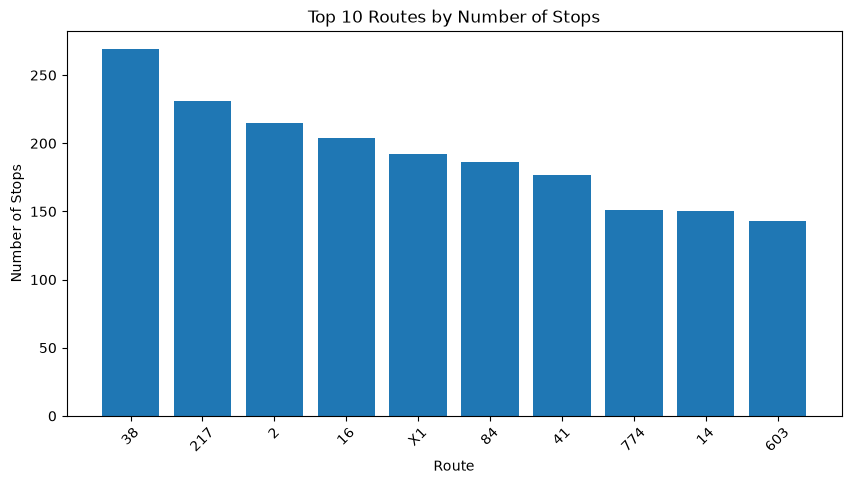

In [104]:
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas
top_routes = (
    df.select("line_name", "number_of_stops")
      .orderBy(desc("number_of_stops"))
      .limit(10)
      .toPandas()
)

plt.figure(figsize=(10,5))

plt.bar(top_routes["line_name"], top_routes["number_of_stops"])

plt.title("Top 10 Routes by Number of Stops")
plt.xlabel("Route")
plt.ylabel("Number of Stops")

plt.xticks(rotation=45)

plt.show()

## Save Processed Data

In [105]:
df.write.mode("overwrite").parquet("../outputs/timetable_parquet")

In [106]:
import os

print(os.listdir("../outputs"))

['models', 'timetable_parquet', 'figures', 'tables']


In [107]:
saved_df = spark.read.parquet("../outputs/timetable_parquet")

saved_df.show(5, truncate=False)

+-------------------+--------------------------------------------------------------------------------------------------------+---------+-------------------+------------------+---------------+----------+--------------------------------------------------+-------------+
|creation_time      |filename                                                                                                |line_name|modified_time      |number_of_journeys|number_of_stops|operator  |route_description                                 |service_code |
+-------------------+--------------------------------------------------------------------------------------------------------+---------+-------------------+------------------+---------------+----------+--------------------------------------------------+-------------+
|2022-08-19T12:05:39|X2-None--SCMY-CZ-2026-03-29-Chester_July_2026_(SchOut)__SCMY_PC1033334_224_20260719-BODS_V1_1.xml       |2        |2026-07-02T13:55:43|141               |215            |Stage

## Summary

In this notebook:

- Loaded the BODS timetable dataset.
- Extracted XML timetable files.
- Parsed relevant transport information from each XML file.
- Created a PySpark DataFrame.
- Performed exploratory data analysis.
- Generated visualizations.
- Saved the processed dataset in Parquet format.